# Manufacturing Robot Predictive Maintenance

## Regression-Based Anomaly Detection

This project extends a robot data-streaming pipeline with a regression-based predictive-maintenance workflow. Linear Regression is used to establish expected current behavior for **Axis #1–#8**. Residual analysis then provides evidence-based thresholds for sustained **Alert** and **Error** conditions.

The notebook presents the finished workflow and key evidence rather than the development process. Supporting database, streaming, dashboard, and synthetic-data functionality is kept in the project `src/` modules.


## Project workflow

**Robot data → PostgreSQL training source → 8 regression models → residual analysis → MinC / MaxC / T → synthetic testing → continuous Alert/Error detection → event log**

The model is intended as an early warning for abnormal operating behavior. It does not claim to predict mechanical failure without failure-history data.
from sklearn.preprocessing import StandardScaler


## Setup and data access

The project uses the repository data and supporting Python modules. When `DATABASE_URL` is available, PostgreSQL is the authoritative training source; the local CSV is retained as a fallback for reproducibility.


In [1]:
import os
import time
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.streaming_simulator import StreamingSimulator
from src.database_service import get_records
from src.database_service import connect_db
from src.database_service import create_table
from src.database_service import insert_record
from src.database_service import insert_dataframe
from src.dashboard import RobotDashboard
from src.synthetic_data_generator import generate_synthetic_testing_data
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


### Database and streaming check

The project uses a dedicated PostgreSQL table, `predictive_maintenance_robot_data`, so the project remains separate from the original workshop schema. A small streaming check confirms that `StreamingSimulator.nextDataPoint()` returns robot observations.


In [ ]:
import os

if os.getenv("DATABASE_URL"):
    db = connect_db()
    db.close()
    print("Database connection successful!")
else:
    print("DATABASE_URL is not configured. Database tests will be skipped until .env is configured.")

if os.getenv("DATABASE_URL"):
    create_table()
    print("predictive_maintenance_robot_data table is ready.")
else:
    print("Skipped database table creation because DATABASE_URL is not configured.")

if os.getenv("DATABASE_URL"):
    insert_record(
        "current",
        0, 0, 0, 0, 0, 0, 0, 0,
        "2022-10-17T12:18:29.222Z"
    )
    print("Test record inserted successfully.")
else:
    print("Skipped database insert because DATABASE_URL is not configured.")

if os.getenv("DATABASE_URL"):
    connection = connect_db()
    with connection.cursor() as cursor:
        cursor.execute("TRUNCATE TABLE predictive_maintenance_robot_data")
    connection.commit()
    connection.close()
    print("predictive_maintenance_robot_data table cleared successfully.")

    source_for_db = pd.read_csv("data/robot_data.csv")
    inserted = insert_dataframe(source_for_db)
    print(f"Training records uploaded to Neon PostgreSQL: {inserted:,}")
else:
    print("Skipped database cleanup/ingestion because DATABASE_URL is not configured.")

ss = StreamingSimulator("data/robot_data.csv")
ss.data.head()

for i in range(5):

    data_point = ss.nextDataPoint()

    if data_point is None:
        break

    display(data_point)

    time.sleep(2)


Database connection successful!
predictive_maintenance_robot_data table is ready.
Test record inserted successfully.
predictive_maintenance_robot_data table cleared successfully.
Training records uploaded to Neon PostgreSQL: 39,672


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
0,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:23.660Z


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
1,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:25.472Z


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
2,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:27.348Z


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
3,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:29.222Z


,Trait,Axis #1,Axis #2,Axis #3,Axis #4,Axis #5,Axis #6,Axis #7,Axis #8,Axis #9,Axis #10,Axis #11,Axis #12,Axis #13,Axis #14,Time
4,current,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2022-10-17T12:18:31.117Z


## Robot operating context

The dataset contains 39,672 records and eight axes. The robot is treated as **RUNNING** when the combined current of Axis #1–#8 exceeds 0.5; otherwise it is **STOPPED**. This separates operating behavior from idle periods before model fitting.


Records: 39,672
Time range: 2022-10-17 12:18:23.660000+00:00 → 2022-10-18 10:44:58.628000+00:00
Running records: 14,047
Stopped records: 25,625


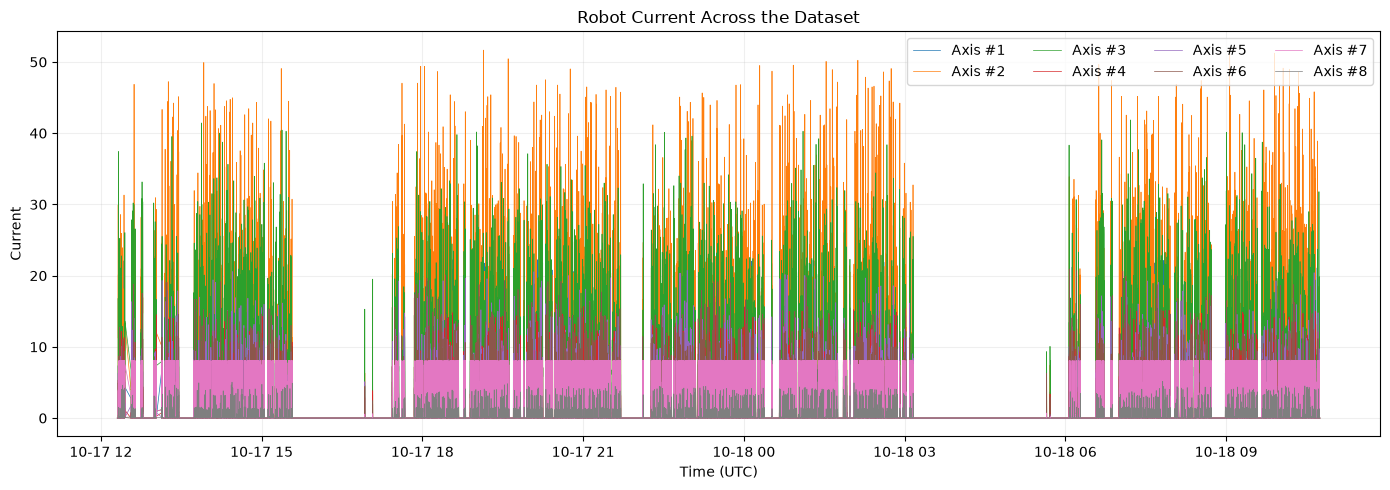

In [3]:
df = pd.read_csv("data/robot_data.csv")
df["Time"] = pd.to_datetime(df["Time"], utc=True)
axes = [f"Axis #{i}" for i in range(1, 9)]
df["Total_Current"] = df[axes].sum(axis=1)
df["State"] = np.where(df["Total_Current"] > 0.5, "RUNNING", "STOPPED")

print(f"Records: {len(df):,}")
print(f"Time range: {df['Time'].min()} → {df['Time'].max()}")
print(f"Running records: {(df['State'] == 'RUNNING').sum():,}")
print(f"Stopped records: {(df['State'] == 'STOPPED').sum():,}")

fig, ax = plt.subplots(figsize=(14, 5))
for axis in axes:
    ax.plot(df["Time"], df[axis], linewidth=0.5, label=axis)
ax.set_title("Robot Current Across the Dataset")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Current")
ax.legend(ncol=4)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## Regression models

Each axis is modeled independently using:

`Current = slope × elapsed_time + intercept`

Models are trained only on RUNNING observations. The table reports the required slope/intercept and supporting error metrics.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

DATA_PATH = "data/robot_data.csv" if os.path.exists("data/robot_data.csv") else "/mnt/data/robot_data(1).csv"
TEST_PATH = "results/synthetic_testing_data.csv"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

axes = [f"Axis #{i}" for i in range(1, 9)]

if os.getenv("DATABASE_URL"):
    train_df = get_records()
    train_df = train_df.rename(columns={"time": "Time", "trait": "Trait"})
    training_source = "Neon PostgreSQL (pulled with get_records())"
else:
    train_df = pd.read_csv(DATA_PATH)
    training_source = "Local CSV fallback (DATABASE_URL not configured)"

train_df["Time"] = pd.to_datetime(train_df["Time"], utc=True, errors="coerce")

missing_axes = [c for c in axes if c not in train_df.columns]
if missing_axes:
    raise ValueError(f"Missing required axis columns: {missing_axes}")

validation_cols = ["Time"] + axes
missing_values = train_df[validation_cols].isna().sum()
duplicate_rows = int(train_df.duplicated().sum())
non_numeric_axes = [c for c in axes if not pd.api.types.is_numeric_dtype(train_df[c])]
negative_axis_counts = (train_df[axes] < 0).sum()

print(f"Training source: {training_source}")
print(f"Training records pulled/loaded: {len(train_df):,}")
print("Missing values in required columns:")
print(missing_values[missing_values > 0].to_string() if (missing_values > 0).any() else "None")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Non-numeric axis columns: {non_numeric_axes if non_numeric_axes else 'None'}")
print("Negative current values by axis:")
print(negative_axis_counts.to_string())

if missing_values.sum() > 0:
    raise ValueError("Required training columns contain missing/invalid values.")
if non_numeric_axes:
    raise TypeError(f"Axis columns must be numeric: {non_numeric_axes}")

train_df["Total_Current_8_Axes"] = train_df[axes].sum(axis=1)
train_df["State_Assignment"] = np.where(train_df["Total_Current_8_Axes"] > 0.5, "RUNNING", "STOPPED")

print(f"Running records: {(train_df['State_Assignment'] == 'RUNNING').sum():,}")
print(f"Stopped records: {(train_df['State_Assignment'] == 'STOPPED').sum():,}")
print(f"Time range: {train_df['Time'].min()} → {train_df['Time'].max()}")

# Train Time -> Axis #1..#8 regression models
train_running = train_df[train_df["State_Assignment"] == "RUNNING"].copy()
t0 = train_df["Time"].min()
train_running["ElapsedSeconds"] = (train_running["Time"] - t0).dt.total_seconds()

regression_models = {}
regression_rows = []

for axis in axes:
    X = train_running[["ElapsedSeconds"]].to_numpy()
    y = train_running[axis].to_numpy()
    model = LinearRegression()
    model.fit(X, y)
    pred = model.predict(X)
    residual = y - pred
    regression_models[axis] = model
    regression_rows.append({
        "Axis": axis,
        "Slope": model.coef_[0],
        "Intercept": model.intercept_,
        "R2": r2_score(y, pred),
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "ResidualMean": residual.mean(),
        "ResidualStd": residual.std(ddof=1)
    })

regression_results = pd.DataFrame(regression_rows)
regression_results.to_csv(os.path.join(RESULTS_DIR, "regression_results.csv"), index=False)
display(regression_results.round(4))


/Users/apple/Desktop/CSCN8010/Assignments/DataStreamVIsual/src/database_service.py:113: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


Training source: Neon PostgreSQL (pulled with get_records())
Training records pulled/loaded: 39,672
Missing values in required columns:
None
Duplicate rows: 0
Non-numeric axis columns: None
Negative current values by axis:
Axis #1    0
Axis #2    0
Axis #3    0
Axis #4    0
Axis #5    0
Axis #6    0
Axis #7    0
Axis #8    0
Running records: 14,047
Stopped records: 25,625
Time range: 2022-10-17 12:18:23.660000+00:00 → 2022-10-18 10:44:58.628000+00:00


,Axis,Slope,Intercept,R2,MAE,RMSE,ResidualMean,ResidualStd
0,Axis #1,-0.0,2.0807,0.0000,2.1298,3.2391,-0.0,3.2392
1,Axis #2,0.0,10.0521,0.0001,5.7841,8.1488,0.0,8.1491
2,Axis #3,-0.0,7.7898,0.0002,4.0608,5.9956,-0.0,5.9958
3,Axis #4,0.0,1.7240,0.0001,1.4739,2.2411,-0.0,2.2412
4,Axis #5,-0.0,2.7111,0.0000,2.0939,2.7861,-0.0,2.7862
5,Axis #6,0.0,1.6551,0.0001,1.7065,2.7307,0.0,2.7308
6,Axis #7,0.0,2.4178,0.0001,2.6081,3.0591,-0.0,3.0592
7,Axis #8,0.0,0.2811,0.0000,0.3370,0.6723,0.0,0.6723


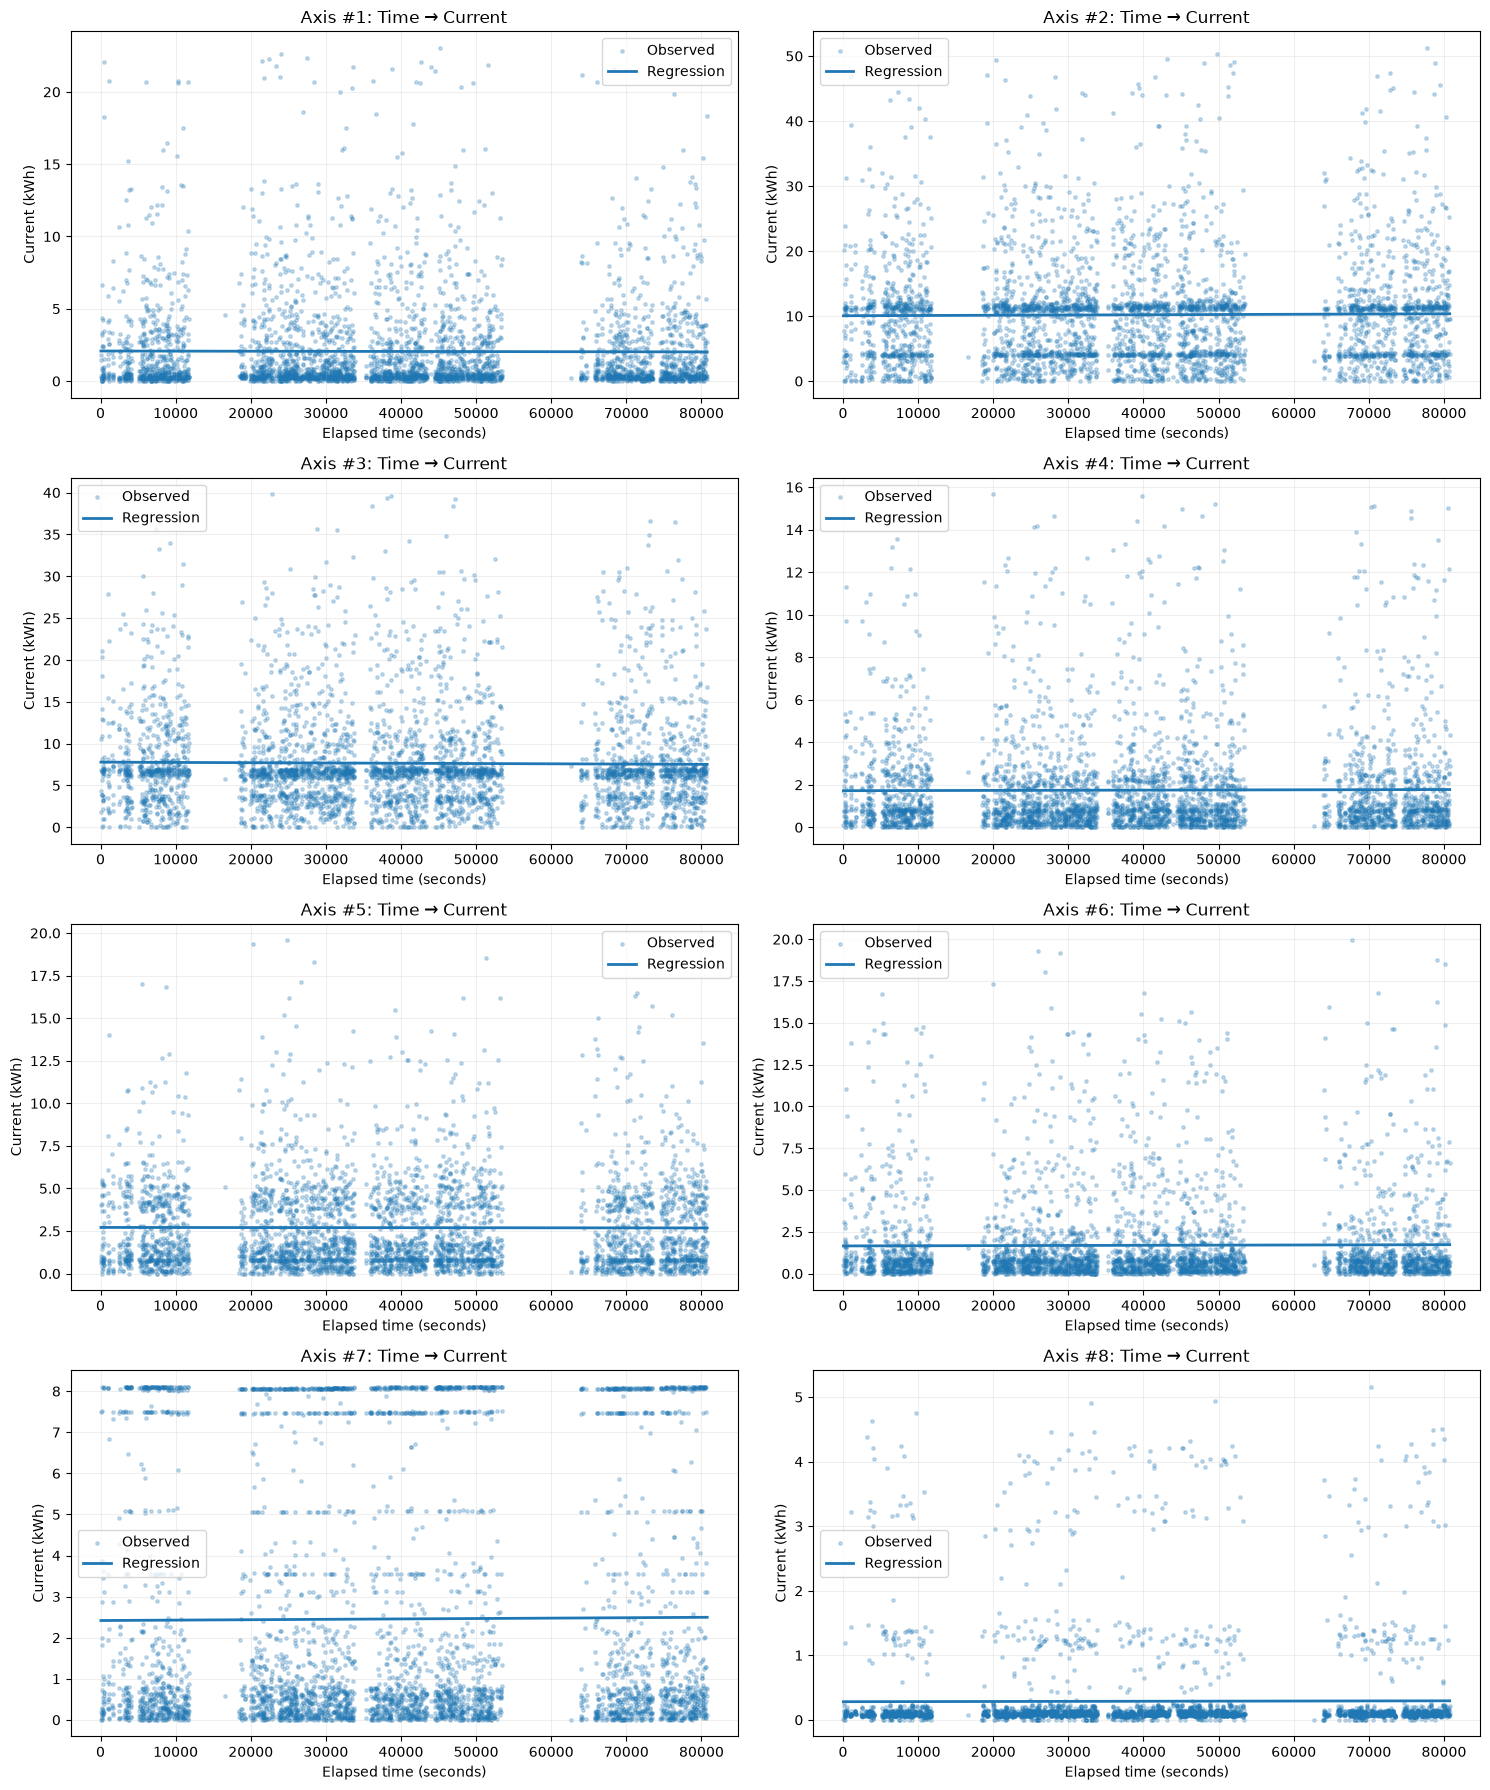

In [5]:
# Regression plots for all eight axes
fig, axes_plot = plt.subplots(4, 2, figsize=(15, 18))
for ax_name, plot_ax in zip(axes, axes_plot.ravel()):
    model = regression_models[ax_name]
    sample = train_running.sample(min(4000, len(train_running)), random_state=42).sort_values("ElapsedSeconds")
    x = sample["ElapsedSeconds"].to_numpy()
    y = sample[ax_name].to_numpy()
    plot_ax.scatter(x, y, s=6, alpha=0.25, label="Observed")
    plot_ax.plot(x, model.predict(x.reshape(-1, 1)), linewidth=2, label="Regression")
    plot_ax.set_title(f"{ax_name}: Time → Current")
    plot_ax.set_xlabel("Elapsed time (seconds)")
    plot_ax.set_ylabel("Current (kWh)")
    plot_ax.legend()
    plot_ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "regression_all_axes.png"), dpi=150, bbox_inches="tight")
plt.show()


## Residual analysis and threshold selection

`Residual = Actual − Predicted`

Positive residuals represent current above the expected regression value.

- **MinC:** 95th percentile of positive training residuals.
- **MaxC:** 99th percentile of positive training residuals.
- **T:** selected from the observed sampling cadence and tested against alternative persistence windows.


,Axis,ResidualStd,PositiveResidualP90,MinC_95thPercentile,MaxC_99thPercentile,PositiveResidualMax
0,Axis #1,3.2392,9.2357,11.6587,19.5045,21.5468
1,Axis #2,8.1491,16.0123,22.0584,34.8640,41.5165
2,Axis #3,5.9958,16.7940,20.6345,26.7717,34.2907
3,Axis #4,2.2412,6.0712,9.0137,11.8835,13.9288
4,Axis #5,2.7862,6.1451,8.5435,14.0033,18.0540
5,Axis #6,2.7308,9.4808,11.7936,15.6124,19.2172
6,Axis #7,3.0592,5.6405,5.6595,5.6802,5.6904
7,Axis #8,0.6723,3.6543,3.8326,4.2092,5.6163


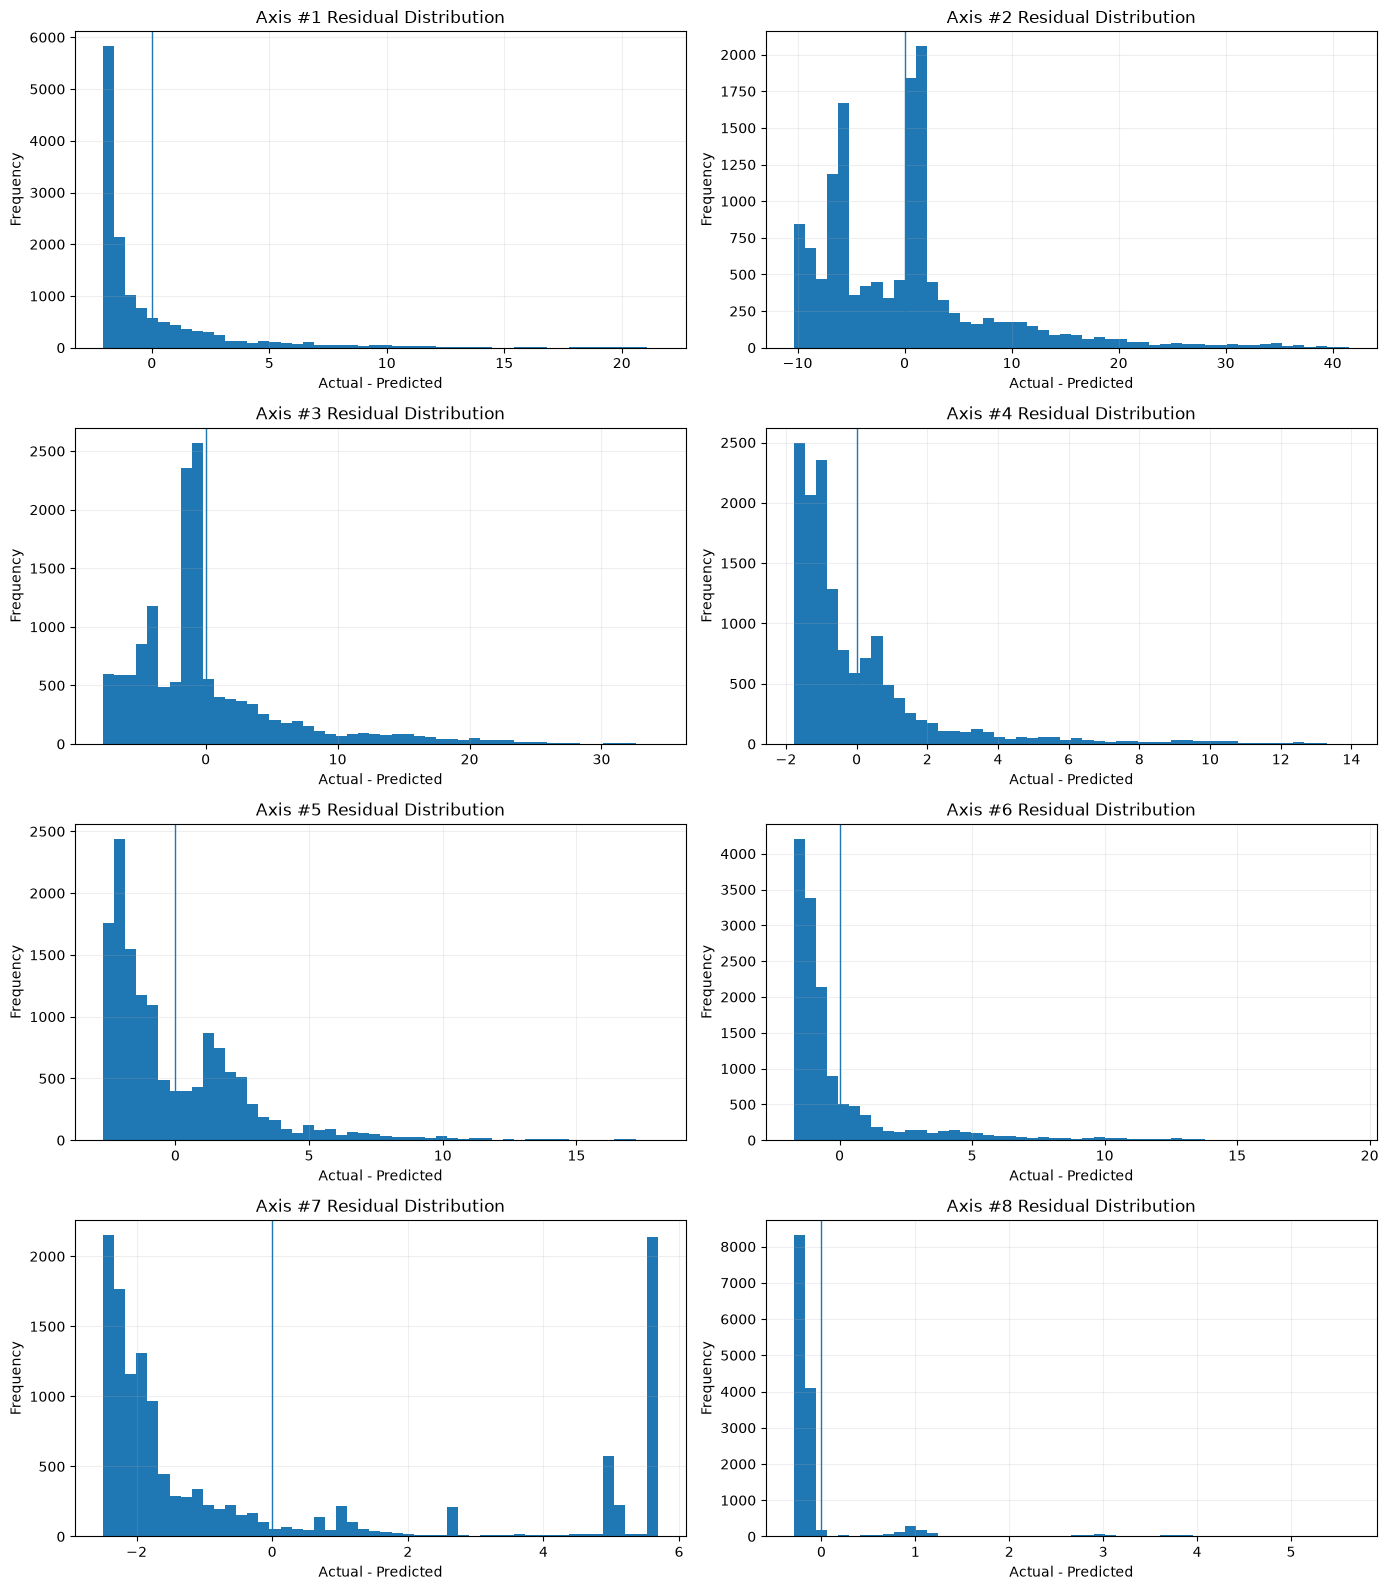

In [6]:
# Residuals, distributions, and candidate MinC/MaxC thresholds
residual_frames = []
threshold_rows = []

for axis in axes:
    model = regression_models[axis]
    x = train_running[["ElapsedSeconds"]].to_numpy()
    actual = train_running[axis].to_numpy()
    predicted = model.predict(x)
    residual = actual - predicted
    positive = residual[residual > 0]
    residual_frames.append(pd.DataFrame({"Axis": axis, "Residual": residual}))
    threshold_rows.append({
        "Axis": axis,
        "ResidualStd": np.std(residual, ddof=1),
        "PositiveResidualP90": np.percentile(positive, 90),
        "MinC_95thPercentile": np.percentile(positive, 95),
        "MaxC_99thPercentile": np.percentile(positive, 99),
        "PositiveResidualMax": np.max(positive)
    })

residual_results = pd.DataFrame(threshold_rows)
residual_results.to_csv(os.path.join(RESULTS_DIR, "residual_threshold_analysis.csv"), index=False)
display(residual_results.round(4))

# Residual distribution plots
fig, plots = plt.subplots(4, 2, figsize=(14, 16))
for axis, plot_ax in zip(axes, plots.ravel()):
    residual = residual_frames[axes.index(axis)]["Residual"]
    plot_ax.hist(residual, bins=50)
    plot_ax.axvline(0, linewidth=1)
    plot_ax.set_title(f"{axis} Residual Distribution")
    plot_ax.set_xlabel("Actual - Predicted")
    plot_ax.set_ylabel("Frequency")
    plot_ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "residual_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

threshold_map = {
    row["Axis"]: {
        "MinC": row["MinC_95thPercentile"],
        "MaxC": row["MaxC_99thPercentile"]
    }
    for _, row in residual_results.iterrows()
}


### Synthetic-data normalization and standardization validation

The synthetic test set is normalized to the training-data range and standardized using statistics learned **only from the training data**. This prevents test-set leakage and keeps the testing stream on the same scale as the relational-database training source. The detector continues to operate in the original current units because the regression models and MinC/MaxC thresholds were trained in those units.


## Synthetic testing and continuous detection

A separate synthetic dataset is generated from the training metadata. It contains normal operation, a controlled sustained Alert scenario, a controlled sustained Error scenario, and recovery. The trained models are not retrained on the testing data.

An event is considered continuous only while the deviation remains above MinC and timestamp gaps remain within the continuity limit. A sustained event reaching MaxC is classified as **ERROR**; otherwise it is **ALERT**.


In [7]:
# Reproducibly generate the testing dataset from training metadata.
test_df, ground_truth = generate_synthetic_testing_data(
    train_df.drop(columns=["Total_Current_8_Axes", "State_Assignment"], errors="ignore"),
    regression_models,
    threshold_map,
    TEST_PATH,
    "results/synthetic_ground_truth.csv",
    n_rows=8000,
    seed=42,
)

test_df["Time"] = pd.to_datetime(test_df["Time"], utc=True)
test_df["ElapsedSeconds"] = (test_df["Time"] - t0).dt.total_seconds()

print(f"Synthetic testing records: {len(test_df):,}")
print(test_df["Synthetic_Event"].value_counts())

# Derive T candidates from the observed normal sampling cadence.
intervals = train_running["Time"].diff().dt.total_seconds().dropna()
normal_interval = float(intervals[intervals <= 3].median())
T_CANDIDATES = [max(4.0, round(normal_interval * 2)),
                max(6.0, round(normal_interval * 3)),
                max(8.0, round(normal_interval * 4))]
T_SECONDS = 6.0
print(f"Median normal sampling interval: {normal_interval:.2f} seconds")
print("T candidates (approximately 2, 3 and 4 samples):", T_CANDIDATES)
print(f"Selected T: {T_SECONDS:.1f} seconds (about {T_SECONDS / normal_interval:.1f} normal samples)")
print("Axis #2 thresholds:", threshold_map["Axis #2"])

def detect_continuous_events(test_data, models, thresholds, min_duration_seconds=6.0, gap_limit_seconds=3.0):
    events = []
    result = test_data.copy()
    for axis in axes:
        model = models[axis]
        elapsed = result[["ElapsedSeconds"]].to_numpy()
        result[f"{axis}_Predicted"] = model.predict(elapsed)
        result[f"{axis}_Residual"] = result[axis] - result[f"{axis}_Predicted"]

        residual = result[f"{axis}_Residual"].to_numpy()
        above_min = residual >= thresholds[axis]["MinC"]
        i = 0
        while i < len(result):
            if not above_min[i]:
                i += 1
                continue
            start = i
            while i + 1 < len(result):
                gap = (result["Time"].iloc[i + 1] - result["Time"].iloc[i]).total_seconds()
                if not above_min[i + 1] or gap > gap_limit_seconds:
                    break
                i += 1
            end = i
            duration = (result["Time"].iloc[end] - result["Time"].iloc[start]).total_seconds()
            if duration >= min_duration_seconds:
                max_deviation = float(residual[start:end + 1].max())
                event_type = "ERROR" if max_deviation >= thresholds[axis]["MaxC"] else "ALERT"
                threshold = thresholds[axis]["MaxC"] if event_type == "ERROR" else thresholds[axis]["MinC"]
                events.append({
                    "axis": axis,
                    "event_type": event_type,
                    "start_time": result["Time"].iloc[start],
                    "end_time": result["Time"].iloc[end],
                    "duration_seconds": duration,
                    "max_deviation": max_deviation,
                    "threshold": threshold,
                    "actual_at_peak": float(result[axis].iloc[start:end + 1].max()),
                    "predicted_at_peak": float(result[f"{axis}_Predicted"].iloc[start:end + 1].iloc[result[axis].iloc[start:end + 1].argmax()])
                })
            i += 1
    return result, pd.DataFrame(events)

scored_test_df, detected_events = detect_continuous_events(
    test_df, regression_models, threshold_map,
    min_duration_seconds=T_SECONDS, gap_limit_seconds=3.0
)

events_path = os.path.join(RESULTS_DIR, "anomaly_events.csv")
detected_events.to_csv(events_path, index=False)
print(f"Detected events: {len(detected_events)}")
display(detected_events)

# Compare detector output with the known synthetic scenarios.
ground_truth_path = "results/synthetic_ground_truth.csv"

ground_truth = pd.read_csv(ground_truth_path)
print("Known synthetic events:")
display(ground_truth)
print("Detected events:")
display(detected_events[["axis","event_type","duration_seconds","max_deviation","threshold"]])

expected_types = set(ground_truth["event_type"].str.upper())
detected_types = set(detected_events["event_type"].str.upper())
print("\nValidation:")
print("Alert detected:", "ALERT" in detected_types)
print("Error detected:", "ERROR" in detected_types)
print("All expected event types detected:", expected_types.issubset(detected_types))

candidate_rows = []
for candidate in T_CANDIDATES:
    _, candidate_events = detect_continuous_events(
        test_df, regression_models, threshold_map,
        min_duration_seconds=float(candidate), gap_limit_seconds=3.0
    )
    candidate_rows.append({
        'T_seconds': float(candidate),
        'Approx_samples': round(float(candidate) / normal_interval, 1),
        'Alert_events': int((candidate_events['event_type'] == 'ALERT').sum()) if not candidate_events.empty else 0,
        'Error_events': int((candidate_events['event_type'] == 'ERROR').sum()) if not candidate_events.empty else 0,
    })
T_comparison = pd.DataFrame(candidate_rows)
display(T_comparison)
print('Selected T = 6 seconds because it requires roughly three consecutive abnormal samples while still detecting both controlled synthetic events.')


Synthetic testing records: 8,000
Synthetic_Event
NORMAL         7982
KNOWN_ALERT       8
KNOWN_ERROR       8
RECOVERY          2
Name: count, dtype: int64
Median normal sampling interval: 1.92 seconds
T candidates (approximately 2, 3 and 4 samples): [4.0, 6.0, 8.0]
Selected T: 6.0 seconds (about 3.1 normal samples)
Axis #2 thresholds: {'MinC': 22.058415775710532, 'MaxC': 34.864008429778934}
Detected events: 2


,axis,event_type,start_time,end_time,duration_seconds,max_deviation,threshold,actual_at_peak,predicted_at_peak
0,Axis #2,ALERT,2022-10-17 13:31:12.972985071+00:00,2022-10-17 13:31:26.442312184+00:00,13.469327,28.461212,22.058416,38.529659,10.068447
1,Axis #2,ERROR,2022-10-17 15:04:44.493322978+00:00,2022-10-17 15:04:57.464347015+00:00,12.971024,41.836810,34.864008,51.926236,10.089426


Known synthetic events:


,event_type,axis,start_index,end_index,duration_seconds,residual_target
0,ALERT,Axis #2,2200,2207,13.469327,28.461212
1,ERROR,Axis #2,5000,5007,12.971024,41.836810


Detected events:


,axis,event_type,duration_seconds,max_deviation,threshold
0,Axis #2,ALERT,13.469327,28.461212,22.058416
1,Axis #2,ERROR,12.971024,41.836810,34.864008



Validation:
Alert detected: True
Error detected: True
All expected event types detected: True


,T_seconds,Approx_samples,Alert_events,Error_events
0,4.0,2.1,1,1
1,6.0,3.1,1,1
2,8.0,4.2,1,1


Selected T = 6 seconds because it requires roughly three consecutive abnormal samples while still detecting both controlled synthetic events.


## Alert and Error results

The controlled synthetic scenarios are recovered by the detector. Axis #2 is used for the detailed visualization because it contains both test scenarios.


In [8]:
# Fit preprocessing statistics on training data only.
standardizer = StandardScaler()
normalizer = MinMaxScaler()
train_axis_values = train_df[axes].fillna(0).astype(float)
test_axis_values = test_df[axes].fillna(0).astype(float)

standardizer.fit(train_axis_values)
normalizer.fit(train_axis_values)
test_standardized = standardizer.transform(test_axis_values)
test_normalized = normalizer.transform(test_axis_values)

standardized_test_df = test_df.copy()
normalized_test_df = test_df.copy()
for i, axis in enumerate(axes):
    standardized_test_df[f"{axis}_Standardized"] = test_standardized[:, i]
    normalized_test_df[f"{axis}_Normalized"] = test_normalized[:, i]

standardization_check = pd.DataFrame({
    "Axis": axes,
    "TrainingMean": train_axis_values.mean().to_numpy(),
    "TrainingStd": train_axis_values.std(ddof=0).to_numpy(),
    "SyntheticMeanStandardized": test_standardized.mean(axis=0),
    "SyntheticStdStandardized": test_standardized.std(axis=0),
})
normalization_check = pd.DataFrame({
    "Axis": axes,
    "TrainingMin": train_axis_values.min().to_numpy(),
    "TrainingMax": train_axis_values.max().to_numpy(),
    "SyntheticMinNormalized": test_normalized.min(axis=0),
    "SyntheticMaxNormalized": test_normalized.max(axis=0),
})

standardization_check.to_csv(os.path.join(RESULTS_DIR, "synthetic_standardization_check.csv"), index=False)
normalization_check.to_csv(os.path.join(RESULTS_DIR, "synthetic_normalization_check.csv"), index=False)
standardized_test_df[["Time"] + [f"{axis}_Standardized" for axis in axes]].to_csv(
    os.path.join(RESULTS_DIR, "synthetic_testing_standardized.csv"), index=False
)
normalized_test_df[["Time"] + [f"{axis}_Normalized" for axis in axes]].to_csv(
    os.path.join(RESULTS_DIR, "synthetic_testing_normalized.csv"), index=False
)
display(standardization_check.round(4))
display(normalization_check.round(4))
print("Normalization and standardization use training-data statistics only; no test-set fitting is performed.")


,Axis,TrainingMean,TrainingStd,SyntheticMeanStandardized,SyntheticStdStandardized
0,Axis #1,0.7257,2.1621,-0.0057,1.0196
1,Axis #2,3.6134,6.8799,0.0218,1.0515
2,Axis #3,2.7103,5.1118,0.0017,0.9990
3,Axis #4,0.6202,1.5749,0.0230,1.0751
4,Axis #5,0.9545,2.1002,0.0021,0.9862
5,Axis #6,0.5994,1.8155,-0.0072,1.0048
6,Axis #7,0.8701,2.1668,0.0090,1.0109
7,Axis #8,0.1022,0.4231,-0.0001,0.9996


,Axis,TrainingMin,TrainingMax,SyntheticMinNormalized,SyntheticMaxNormalized
0,Axis #1,0.0,23.6093,0.0,1.0000
1,Axis #2,0.0,51.7132,0.0,1.0041
2,Axis #3,0.0,41.8556,0.0,1.0000
3,Axis #4,0.0,15.6663,0.0,0.9951
4,Axis #5,0.0,20.7508,0.0,0.9900
5,Axis #6,0.0,20.9314,0.0,0.9889
6,Axis #7,0.0,8.1085,0.0,1.0000
7,Axis #8,0.0,5.9056,0.0,1.0000


Normalization and standardization use training-data statistics only; no test-set fitting is performed.


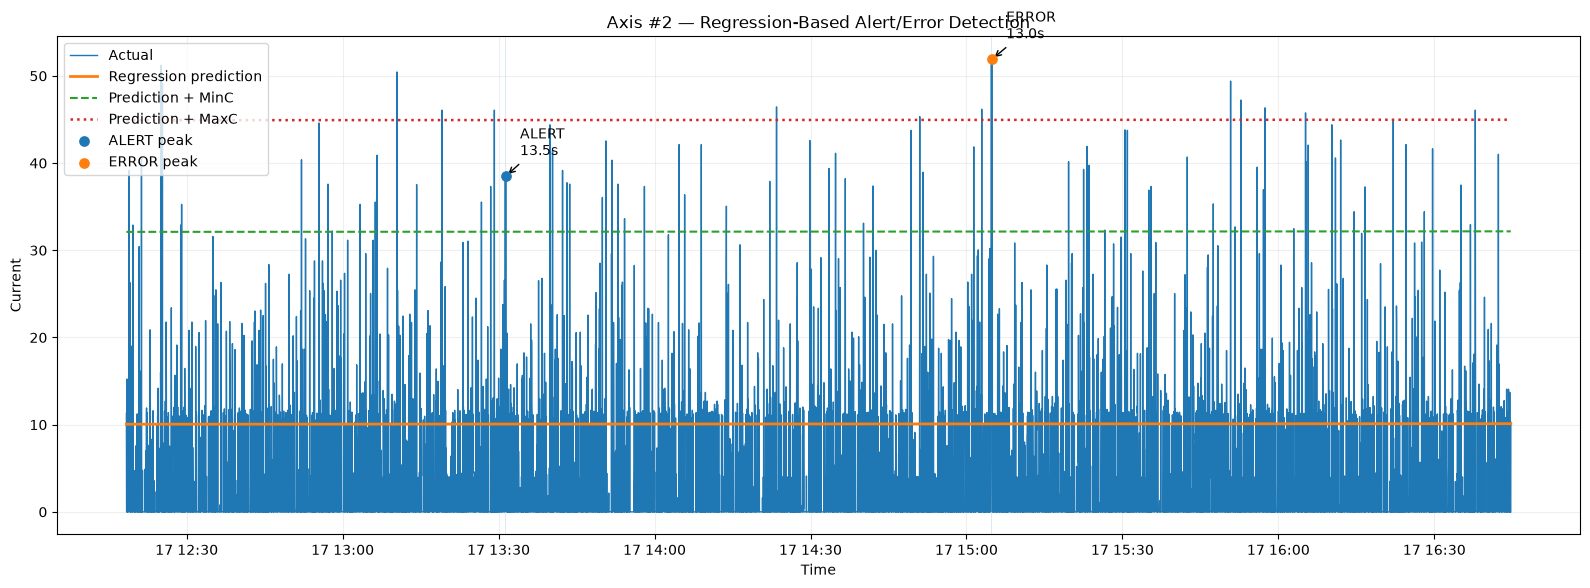

FINAL CANDIDATE THRESHOLDS


,Axis,MinC_95thPercentile,MaxC_99thPercentile,T_seconds
0,Axis #1,11.6587,19.5045,6.0
1,Axis #2,22.0584,34.8640,6.0
2,Axis #3,20.6345,26.7717,6.0
3,Axis #4,9.0137,11.8835,6.0
4,Axis #5,8.5435,14.0033,6.0
5,Axis #6,11.7936,15.6124,6.0
6,Axis #7,5.6595,5.6802,6.0
7,Axis #8,3.8326,4.2092,6.0



Event log saved to: results/anomaly_events.csv
Regression results saved to: results/regression_results.csv


In [9]:
axis = "Axis #2"
fig, ax = plt.subplots(figsize=(16, 6))
actual = scored_test_df[axis]
predicted = scored_test_df[f"{axis}_Predicted"]
minc = threshold_map[axis]["MinC"]
maxc = threshold_map[axis]["MaxC"]

ax.plot(scored_test_df["Time"], actual, linewidth=1, label="Actual")
ax.plot(scored_test_df["Time"], predicted, linewidth=2, label="Regression prediction")
ax.plot(scored_test_df["Time"], predicted + minc, linestyle="--", linewidth=1.5, label="Prediction + MinC")
ax.plot(scored_test_df["Time"], predicted + maxc, linestyle=":", linewidth=1.8, label="Prediction + MaxC")

for _, event in detected_events[detected_events["axis"] == axis].iterrows():
    start = pd.to_datetime(event["start_time"], utc=True)
    end = pd.to_datetime(event["end_time"], utc=True)
    event_mask = (scored_test_df["Time"] >= start) & (scored_test_df["Time"] <= end)
    peak_idx = scored_test_df.loc[event_mask, axis].idxmax()
    peak_time = scored_test_df.loc[peak_idx, "Time"]
    peak_value = scored_test_df.loc[peak_idx, axis]
    ax.axvspan(start, end, alpha=0.15)
    ax.scatter([peak_time], [peak_value], s=45, zorder=5, label=f'{event["event_type"]} peak')
    ax.annotate(
        f'{event["event_type"]}\n{event["duration_seconds"]:.1f}s',
        xy=(peak_time, peak_value), xytext=(10, 15), textcoords="offset points",
        arrowprops={"arrowstyle": "->"}
    )

ax.set_title("Axis #2 — Regression-Based Alert/Error Detection")
ax.set_xlabel("Time")
ax.set_ylabel("Current")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "axis2_alert_error_detection.png"), dpi=150, bbox_inches="tight")
plt.show()

# Compact final results table for the report/README.
final_thresholds = residual_results[["Axis", "MinC_95thPercentile", "MaxC_99thPercentile"]].copy()
final_thresholds["T_seconds"] = T_SECONDS
final_thresholds.to_csv(os.path.join(RESULTS_DIR, "final_thresholds.csv"), index=False)

print("FINAL CANDIDATE THRESHOLDS")
display(final_thresholds.round(4))
print("\nEvent log saved to:", events_path)
print("Regression results saved to:", os.path.join(RESULTS_DIR, "regression_results.csv"))


## Threshold justification and interpretation

The thresholds are data-driven rather than arbitrary. MinC and MaxC are derived from the positive residual distribution of the training data, while **T = 6 seconds** corresponds to roughly three normal observations at the observed ~1.9-second sampling interval. This reduces the chance that a single short spike becomes an alert while retaining the ability to detect sustained abnormal behavior.

The resulting system provides an early warning workflow: **expected current → deviation → sustained threshold crossing → Alert/Error → maintenance investigation**. The event log is saved to `results/anomaly_events.csv`, while model, threshold, testing, and visualization outputs are stored in `results/`.

### Reproducibility

Run the notebook from the project root with the project's Python environment and dependencies from `requirements.txt`. Keep database credentials in `.env`; do not commit the `.env` file.


## Final submission validation

Run this cell last. It confirms that the key result files were produced. **Save the notebook after running it** so the final execution outputs are embedded in the submitted `.ipynb`, satisfying the submission-output requirement.


In [10]:
# Final submission validation
required_outputs = [
    "results/regression_results.csv",
    "results/residual_threshold_analysis.csv",
    "results/final_thresholds.csv",
    "results/synthetic_ground_truth.csv",
    "results/anomaly_events.csv",
    "results/regression_all_axes.png",
    "results/residual_distributions.png",
    "results/axis2_alert_error_detection.png",
    "results/synthetic_standardization_check.csv",
    "results/synthetic_normalization_check.csv"
]
missing_outputs = [path for path in required_outputs if not os.path.exists(path)]
print("FINAL SUBMISSION VALIDATION")
print("Required result files: ", len(required_outputs) - len(missing_outputs), "/", len(required_outputs))
if missing_outputs:
    print("Missing files:")
    for path in missing_outputs:
        print(" -", path)
else:
    print("All required result files are present.")

assert not missing_outputs, "Final validation failed: one or more required result files are missing."
print("Notebook final run completed successfully. Save the notebook after this cell runs so its outputs are embedded in the .ipynb.")


FINAL SUBMISSION VALIDATION
Required result files:  10 / 10
All required result files are present.
Notebook final run completed successfully. Save the notebook after this cell runs so its outputs are embedded in the .ipynb.
